Meilleurs paramètres: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500}
Meilleur score CV: 0.815625
Accuracy validation : 0.8
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        40
           1       0.77      0.85      0.81        40

    accuracy                           0.80        80
   macro avg       0.80      0.80      0.80        80
weighted avg       0.80      0.80      0.80        80

AUC validation : 0.86125


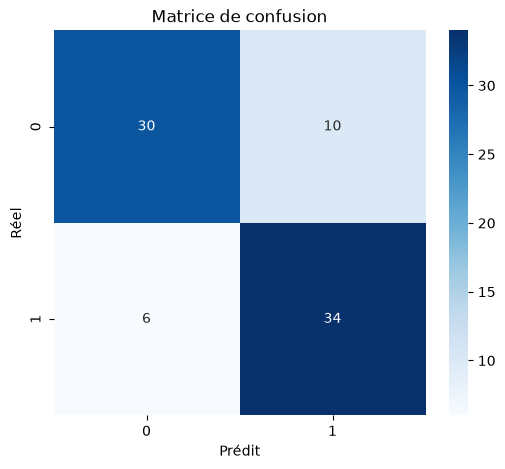

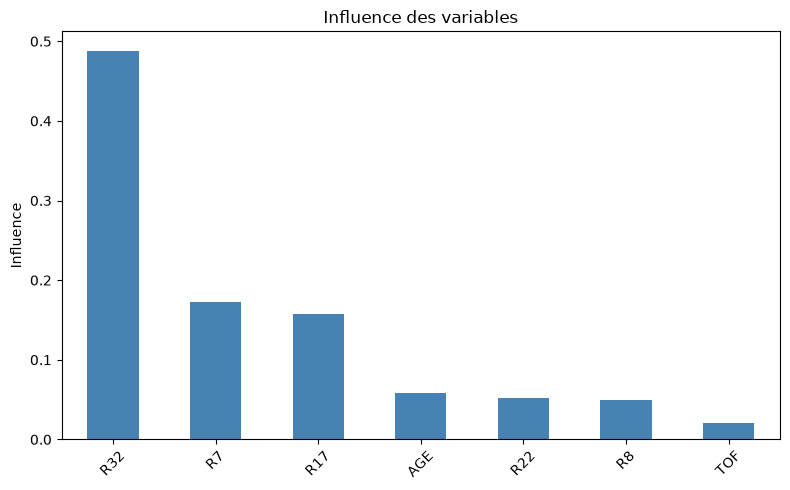

   ID  DIFF
0   1     0
1   2     1
2   3     1
3   4     1
4   5     1


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# chargement des données
train = pd.read_csv("https://raw.githubusercontent.com/noahchrgs/DemiJourneeData/main/data/farms_train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/noahchrgs/DemiJourneeData/main/data/farms_test.csv")
submission_template = pd.read_csv("https://raw.githubusercontent.com/noahchrgs/DemiJourneeData/main/data/ex_soumission.csv")

X = train.drop(columns=["DIFF"])
y = train["DIFF"]

# split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#tuning du modèle
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Meilleurs paramètres:", grid.best_params_)
print("Meilleur score CV:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_val)

# évaluation
print("Accuracy validation :", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

# auc
y_proba = best_model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, y_proba)
print("AUC validation :", auc_score)

# matrice de confusion
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["0", "1"], yticklabels=["0", "1"])
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# influence des variables 
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar", color="steelblue")
plt.title("Influence des variables")
plt.ylabel("Influence")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# entraînement final sur tout le dataset
final_model = grid.best_estimator_
final_model.fit(X, y)

pred_test = final_model.predict(test)

# soumission
submission = pd.DataFrame({
    "ID": submission_template["ID"],
    "DIFF": pred_test
})

submission.to_csv("submission.csv", index=False)
print(submission.head())
